# Процес обучения алгоритма регрессии

1. Предобработка данных
2. Разделение (train/test)
3. Выборка модели и гиперпараметров
4. Оптимизация параметров (Обучение)
5. Оценка по метрикам, проверка, переобучение
6. Кросс-валидация (CV) - для более стабильной оценки

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import learning_curve

In [168]:
FILE_PATH = 'Housing.csv'
data = pd.read_csv(FILE_PATH)

# EDA (Exploratory Data Analysis) - Первичный анализ данных

In [169]:
data.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850.0,3,1,2,yes,no,yes,no,no,1.0,no
1,2,38500,4000.0,2,1,1,yes,no,no,no,no,0.0,no
2,3,49500,3060.0,3,1,1,yes,no,no,no,no,0.0,no
3,4,60500,6650.0,3,1,2,yes,yes,no,no,no,0.0,no
4,5,61000,6360.0,2,1,1,yes,no,no,no,no,0.0,no


In [170]:
data.shape

(546, 13)

In [171]:
data.dtypes

rownames      int64
price         int64
lotsize     float64
bedrooms      int64
bathrms       int64
stories       int64
driveway        str
recroom         str
fullbase        str
gashw           str
airco           str
garagepl    float64
prefarea        str
dtype: object

In [172]:
data.isna().sum()

rownames    0
price       0
lotsize     5
bedrooms    0
bathrms     0
stories     0
driveway    2
recroom     4
fullbase    0
gashw       2
airco       7
garagepl    2
prefarea    2
dtype: int64

In [173]:
data.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,541.000000,546.000000,546.000000,546.000000,544.000000
mean,273.500000,68121.597070,5160.611830,2.965201,1.285714,1.807692,0.694853
std,157.760895,26702.670926,2175.141222,0.737388,0.502158,0.868203,0.861864
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3584.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


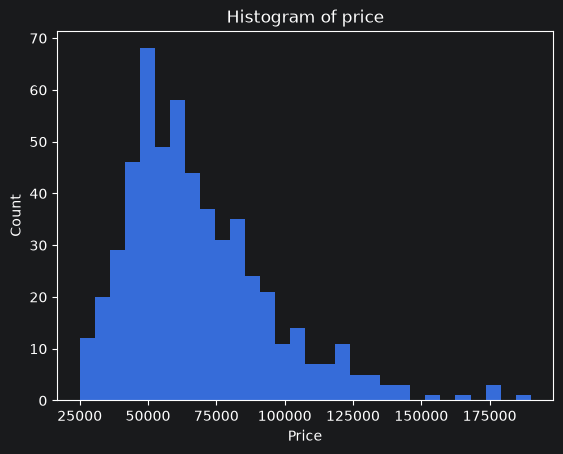

In [174]:
plt.figure()
plt.hist(data['price'], bins=30)
plt.title('Histogram of price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

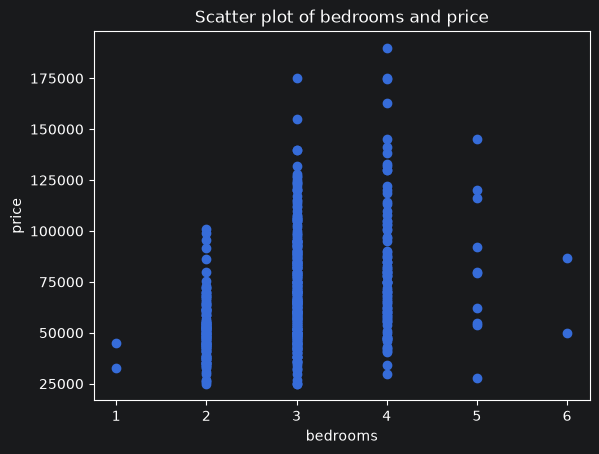

In [175]:
plt.figure()
plt.scatter(data['bedrooms'], data['price'])
plt.title('Scatter plot of bedrooms and price')
plt.xlabel('bedrooms')
plt.ylabel('price')
plt.show()

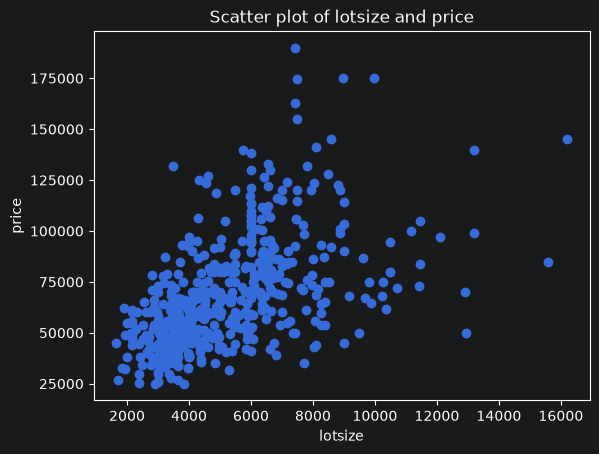

In [176]:
plt.figure()
plt.scatter(data['lotsize'], data['price'])
plt.title('Scatter plot of lotsize and price')
plt.xlabel('lotsize')
plt.ylabel('price')
plt.show()

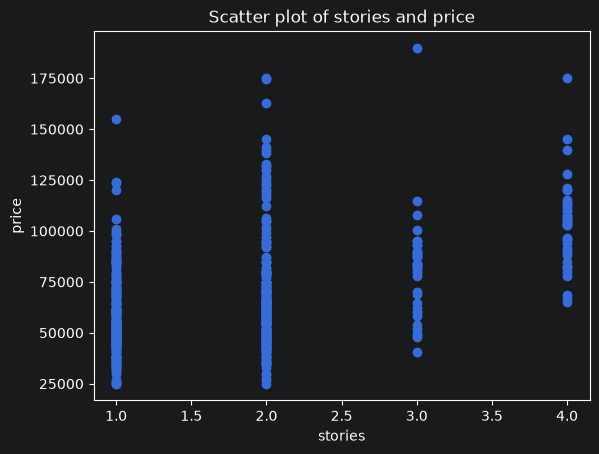

In [177]:
plt.figure()
plt.scatter(data['stories'], data['price'])
plt.title('Scatter plot of stories and price')
plt.xlabel('stories')
plt.ylabel('price')
plt.show()

In [178]:
target_col = 'price'
numeric_cols = ['lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl']
potential_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

In [179]:
categorial_cols = [c for c in potential_cols if c in data.columns]
all_used_cols = numeric_cols + categorial_cols + [target_col]
data = data[all_used_cols].copy()

In [180]:
data.head()

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850.0,3,1,2,1.0,yes,no,yes,no,no,no,42000
1,4000.0,2,1,1,0.0,yes,no,no,no,no,no,38500
2,3060.0,3,1,1,0.0,yes,no,no,no,no,no,49500
3,6650.0,3,1,2,0.0,yes,yes,no,no,no,no,60500
4,6360.0,2,1,1,0.0,yes,no,no,no,no,no,61000


# Factorize

In [181]:
data_factorized = data.copy()
factorize_maps = {}
for col in categorial_cols:
    codes, uniques = pd.factorize(data_factorized[col])
    data_factorized[col] = codes
    factorize_maps[col] = list(uniques)
display(data_factorized.head())
factorize_maps

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850.0,3,1,2,1.0,0,0,0,0,0,0,42000
1,4000.0,2,1,1,0.0,0,0,1,0,0,0,38500
2,3060.0,3,1,1,0.0,0,0,1,0,0,0,49500
3,6650.0,3,1,2,0.0,0,1,1,0,0,0,60500
4,6360.0,2,1,1,0.0,0,0,1,0,0,0,61000


{'driveway': ['yes', 'no'],
 'recroom': ['no', 'yes'],
 'fullbase': ['yes', 'no'],
 'gashw': ['no', 'yes'],
 'airco': ['no', 'yes'],
 'prefarea': ['no', 'yes']}

# OHE - One Hot Encoder - One Hot кодирование

In [182]:
data_onehot = pd.get_dummies(data_factorized, columns=categorial_cols, drop_first=True)
display(data_onehot.head())

,lotsize,bedrooms,bathrms,stories,garagepl,price,driveway_0,driveway_1,recroom_0,recroom_1,fullbase_1,gashw_0,gashw_1,airco_0,airco_1,prefarea_0,prefarea_1
0,5850.0,3,1,2,1.0,42000,True,False,True,False,False,True,False,True,False,True,False
1,4000.0,2,1,1,0.0,38500,True,False,True,False,True,True,False,True,False,True,False
2,3060.0,3,1,1,0.0,49500,True,False,True,False,True,True,False,True,False,True,False
3,6650.0,3,1,2,0.0,60500,True,False,False,True,True,True,False,True,False,True,False
4,6360.0,2,1,1,0.0,61000,True,False,True,False,True,True,False,True,False,True,False


In [183]:
data.head()

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850.0,3,1,2,1.0,yes,no,yes,no,no,no,42000
1,4000.0,2,1,1,0.0,yes,no,no,no,no,no,38500
2,3060.0,3,1,1,0.0,yes,no,no,no,no,no,49500
3,6650.0,3,1,2,0.0,yes,yes,no,no,no,no,60500
4,6360.0,2,1,1,0.0,yes,no,no,no,no,no,61000


# Масштабирование
1. MinMaxScaler()
$$
x'=\frac{x-x_{min}}{x_{max} - x_{min}}
$$
2. StandardScaler()
$$
x' = \frac{x-\mu}{\sigma}
$$

In [184]:
num_demo = data[numeric_cols].copy()
mms = MinMaxScaler()
std_scaler = StandardScaler()
num_demo_mms = pd.DataFrame(mms.fit_transform(num_demo), columns=numeric_cols)
num_demo_std = pd.DataFrame(std_scaler.fit_transform(num_demo), columns=numeric_cols)
print('Min Max scaled data')
display(num_demo_mms.head())
print()
print("Standard Scaled data")
display(num_demo_std.head())

Min Max scaled data


,lotsize,bedrooms,bathrms,stories,garagepl
0,0.288660,0.4,0.0,0.333333,0.333333
1,0.161512,0.2,0.0,0.000000,0.000000
2,0.096907,0.4,0.0,0.000000,0.000000
3,0.343643,0.4,0.0,0.333333,0.000000
4,0.323711,0.2,0.0,0.000000,0.000000



Standard Scaled data


,lotsize,bedrooms,bathrms,stories,garagepl
0,0.317233,0.047235,-0.569495,0.221704,0.354381
1,-0.534074,-1.310147,-0.569495,-0.931157,-0.806963
2,-0.966630,0.047235,-0.569495,-0.931157,-0.806963
3,0.685365,0.047235,-0.569495,0.221704,-0.806963
4,0.551917,-1.310147,-0.569495,-0.931157,-0.806963


# SimpleImputer
- mean
- median
- most_frequent
- constant

In [185]:
data_impute_demo = data.copy()
data_impute_demo.head(18)

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850.0,3,1,2,1.0,yes,no,yes,no,no,no,42000
1,4000.0,2,1,1,0.0,yes,no,no,no,no,no,38500
2,3060.0,3,1,1,0.0,yes,no,no,no,no,no,49500
3,6650.0,3,1,2,0.0,yes,yes,no,no,no,no,60500
4,6360.0,2,1,1,0.0,yes,no,no,no,no,no,61000
5,4160.0,3,1,1,0.0,yes,yes,yes,no,yes,no,66000
6,3880.0,3,2,2,2.0,yes,no,yes,no,no,no,66000
7,4160.0,3,1,3,0.0,yes,no,no,no,no,no,69000
8,4800.0,3,1,1,0.0,yes,yes,yes,no,no,no,83800
9,5500.0,3,2,4,1.0,yes,yes,no,no,NaN,no,88500


In [186]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
data_impute_demo[numeric_cols] = num_imputer.fit_transform(data_impute_demo[numeric_cols])
data_impute_demo[categorial_cols] = cat_imputer.fit_transform(data_impute_demo[categorial_cols])
data_impute_demo.isna().sum()

lotsize     0
bedrooms    0
bathrms     0
stories     0
garagepl    0
driveway    0
recroom     0
fullbase    0
gashw       0
airco       0
prefarea    0
price       0
dtype: int64

In [187]:
data_impute_demo.head(18)

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850.0,3.0,1.0,2.0,1.0,yes,no,yes,no,no,no,42000
1,4000.0,2.0,1.0,1.0,0.0,yes,no,no,no,no,no,38500
2,3060.0,3.0,1.0,1.0,0.0,yes,no,no,no,no,no,49500
3,6650.0,3.0,1.0,2.0,0.0,yes,yes,no,no,no,no,60500
4,6360.0,2.0,1.0,1.0,0.0,yes,no,no,no,no,no,61000
5,4160.0,3.0,1.0,1.0,0.0,yes,yes,yes,no,yes,no,66000
6,3880.0,3.0,2.0,2.0,2.0,yes,no,yes,no,no,no,66000
7,4160.0,3.0,1.0,3.0,0.0,yes,no,no,no,no,no,69000
8,4800.0,3.0,1.0,1.0,0.0,yes,yes,yes,no,no,no,83800
9,5500.0,3.0,2.0,4.0,1.0,yes,yes,no,no,no,no,88500


# Feature engineering

In [188]:
data_fe = data.copy()
data_fe['rooms_total'] = data_fe['bedrooms'] + data_fe['bathrms']
data_fe["lot_per"] = data_fe['lotsize'] / np.where(
    data_fe['rooms_total'] > 0,
    data_fe['rooms_total'],
    1
)

data_fe[['lotsize','bedrooms','bathrms','rooms_total', 'lot_per']].head()

,lotsize,bedrooms,bathrms,rooms_total,lot_per
0,5850.0,3,1,4,1462.500000
1,4000.0,2,1,3,1333.333333
2,3060.0,3,1,4,765.000000
3,6650.0,3,1,4,1662.500000
4,6360.0,2,1,3,2120.000000


In [189]:
X = data_fe.drop(columns=[target_col])
y = data_fe[target_col]

# Test/Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = numeric_cols + ['rooms_total', 'lot_per']
cat_features = categorial_cols

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorial_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorial_transformer, cat_features),
    ]
)

linreg_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linreg_model.fit(X_train, y_train)
y_pred = linreg_model.predict(X_test)

# MAE - Mean Absolute Error
$$
MAE = \frac{1}{n}\sum{|y_i - \hat{y_i}|}
$$
# MSE - Mean Squared Error
$$
MSE = \frac{1}{n}\sum{(y_i - \hat{y_i})^2}
$$

# RMSE - Root Mean Squared Error
$$
RMSE = \sqrt{MSE}
$$
# $R^2$ - R squared
$$
R^2 = 1 - \frac{\text{Ошибка нашей модели}}{\text{ошибка модели, которая всегда предсказывает среднее}}
$$

In [190]:
# Metrics (MAE, MSE, RMSE, R2_Score)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"""
MAE: {mae:.3f}
MSE: {mse:.3f}
RMSE: {rmse:.3f}
R2: {r2:.3f}
""")


MAE: 11178.712
MSE: 252780232.049
RMSE: 15899.064
R2: 0.622



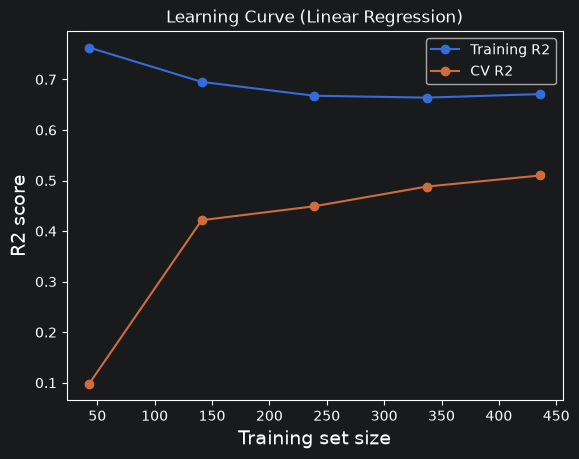

In [191]:
train_sizes, train_scores, test_scores = learning_curve(
    linreg_model,
    X,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(.1, 1.0, 5),
    n_jobs=None,
    shuffle=True,
    random_state=42)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label='Training R2', marker='o')
plt.plot(train_sizes, test_mean, 'o-', label='CV R2', )
plt.title('Learning Curve (Linear Regression)')
plt.ylabel('R2 score', fontsize=14)
plt.xlabel('Training set size', fontsize=14)
plt.legend(loc='best')
plt.show()